In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Load Dataset

In [2]:
df=pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


In [4]:
df.describe()

,Weight,Height
count,23.000000,23.000000
mean,73.826087,158.391304
std,17.872407,19.511626
min,45.000000,120.000000
25%,59.000000,142.500000
50%,78.000000,162.000000
75%,86.000000,175.000000
max,105.000000,183.000000


In [5]:
df.isnull().sum()

Weight    0
Height    0
dtype: int64

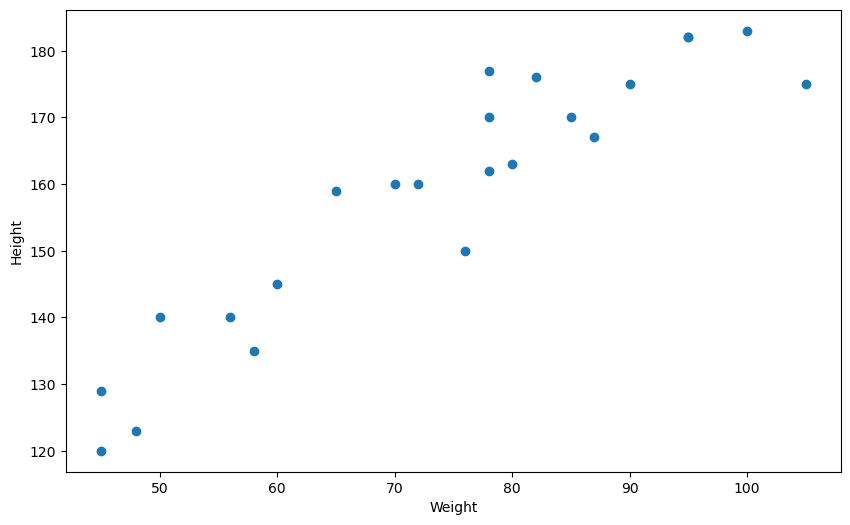

In [6]:
plt.figure(figsize=(10,6))
plt.scatter(x=df['Weight'],y=df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

Divide dataset into dependent and independent features.

In [7]:
X=df[['Weight']]
y=df['Height']

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)



In [9]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((18, 1), (18,), (5, 1), (5,))

In [10]:
X_train

,Weight
12,105
1,58
13,100
5,78
2,48
11,95
20,45
3,60
4,70
18,76


## Standardizing the data 


In [11]:
#Wherever there is ditance based algorithms,wherever there is optimization kind of algorithms there we will use 
#Standardize the dataset train independent features.
#Applying the Z score formular
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [12]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)



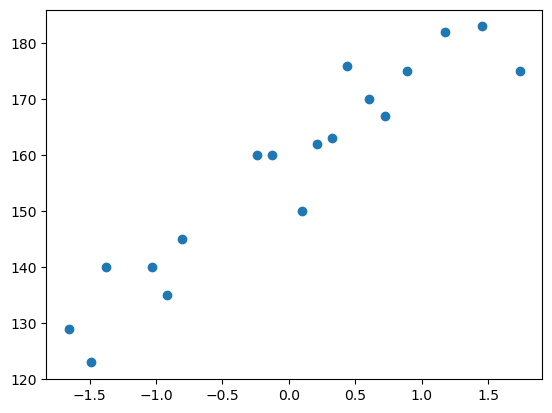

In [13]:
plt.scatter(X_train,y_train)
plt.show()

## Train the model

In [14]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [15]:
coeff=model.coef_
print("The slope/Coefficient of weight is ",coeff)

The slope/Coefficient of weight is  [17.03440872]


In [16]:
intercept=model.intercept_
print("The Intercept is ",intercept)

The Intercept is  157.5


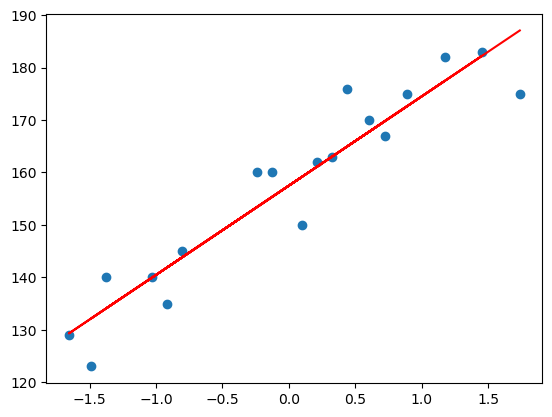

In [17]:
plt.scatter(X_train,y_train)
plt.plot(X_train,model.predict(X_train),'r')
plt.show()

In [18]:
y_pred_test=model.predict(X_test)

Performance metrics

In [20]:
## MSE,RMSE,MAE
## R square and adjusted r square

from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mse=mean_squared_error(y_test,y_pred_test)
rmse=np.sqrt(mse)
mae=mean_absolute_error(y_test,y_pred_test)
print('MSE',mse)
print('RMSE',rmse)
print('MAE',mae)

MSE 109.77592599051654
RMSE 10.477400726827076
MAE 9.822657814519227


In [21]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred_test)
print('R square',r2)

R square 0.7769869860423441


Cross Validation

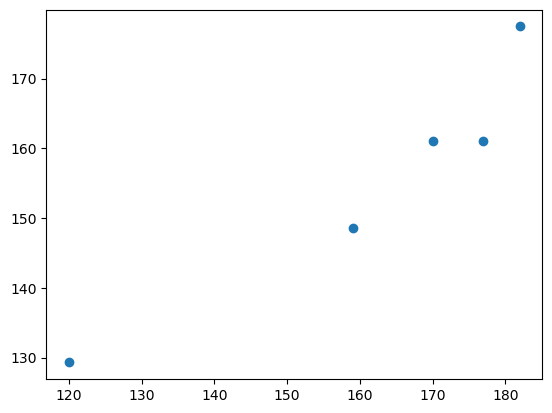

In [23]:
## Assumptions
plt.scatter(y_test,y_pred_test)
plt.show()

In [24]:
## Residuals
residual=y_test-y_pred_test
print(residual)

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64


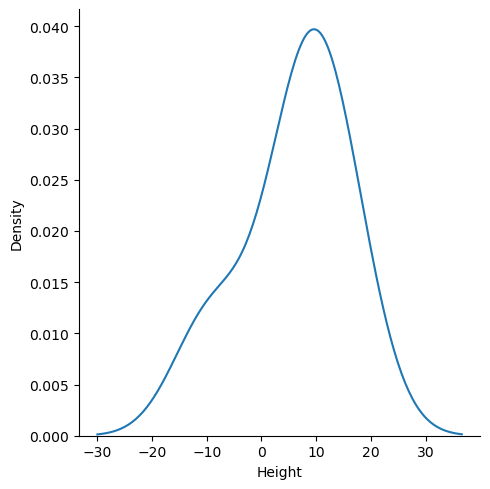

In [32]:
sns.displot(residual,kind='kde')
plt.show()